In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [2]:
df=pd.read_csv(r"C:\Users\dhakshina\Downloads\world_tourism_economy_data.csv")
df

,country,country_code,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
0,Aruba,ABW,1999,7.820000e+08,9.720000e+05,62.542949,NaN,9.495387,1.722905e+09,2.280372,NaN
1,Africa Eastern and Southern,AFE,1999,8.034209e+09,1.530938e+07,12.204030,NaN,7.760536,2.654293e+11,7.819865,NaN
2,Afghanistan,AFG,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,1999,1.443613e+09,3.897975e+06,3.974476,NaN,6.147291,1.394683e+11,0.372266,NaN
4,Angola,AGO,1999,3.100000e+07,4.500000e+04,0.583858,NaN,2.489638,6.152923e+09,248.195902,NaN
...,...,...,...,...,...,...,...,...,...,...,...
6645,Kosovo,XKX,2023,NaN,NaN,NaN,NaN,NaN,1.046822e+10,4.944324,NaN
6646,"Yemen, Rep.",YEM,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6647,South Africa,ZAF,2023,NaN,NaN,NaN,NaN,NaN,3.806993e+11,6.073909,32.098
6648,Zambia,ZMB,2023,NaN,NaN,NaN,NaN,NaN,2.757796e+10,10.884532,NaN


In [3]:
# Initial Analysis
df.shape

(6650, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               6650 non-null   object 
 1   country_code          6650 non-null   object 
 2   year                  6650 non-null   int64  
 3   tourism_receipts      4289 non-null   float64
 4   tourism_arrivals      4949 non-null   float64
 5   tourism_exports       4114 non-null   float64
 6   tourism_departures    2589 non-null   float64
 7   tourism_expenditures  4173 non-null   float64
 8   gdp                   6424 non-null   float64
 9   inflation             5668 non-null   float64
 10  unemployment          3658 non-null   float64
dtypes: float64(8), int64(1), object(2)
memory usage: 571.6+ KB


In [5]:
df.head()

,country,country_code,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
0,Aruba,ABW,1999,7.820000e+08,9.720000e+05,62.542949,NaN,9.495387,1.722905e+09,2.280372,NaN
1,Africa Eastern and Southern,AFE,1999,8.034209e+09,1.530938e+07,12.204030,NaN,7.760536,2.654293e+11,7.819865,NaN
2,Afghanistan,AFG,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,1999,1.443613e+09,3.897975e+06,3.974476,NaN,6.147291,1.394683e+11,0.372266,NaN
4,Angola,AGO,1999,3.100000e+07,4.500000e+04,0.583858,NaN,2.489638,6.152923e+09,248.195902,NaN


In [6]:
# Checking for missing values
df.isnull().sum().sort_values(ascending=False)

tourism_departures      4061
unemployment            2992
tourism_exports         2536
tourism_expenditures    2477
tourism_receipts        2361
tourism_arrivals        1701
inflation                982
gdp                      226
year                       0
country                    0
country_code               0
dtype: int64

In [113]:
df['tourism_receipts'] = df['tourism_receipts'].fillna(df['tourism_receipts'].mean())
df['tourism_arrivals'] = df['tourism_arrivals'].fillna(df['tourism_arrivals'].mean())
df['tourism_departures'] = df['tourism_departures'].fillna(df['tourism_departures'].mean())

df['gdp'] = df['gdp'].fillna(df['gdp'].mean())

df

,country,country_code,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment,receipts_pct_gdp
0,Aruba,ABW,1999,7.820000e+08,9.720000e+05,62.542949,8.246093e+07,9.495387,1.722905e+09,2.280372,NaN,45.388457
1,Africa Eastern and Southern,AFE,1999,8.034209e+09,1.530938e+07,12.204030,8.246093e+07,7.760536,2.654293e+11,7.819865,NaN,3.026874
2,Afghanistan,AFG,1999,3.062956e+10,6.263894e+07,NaN,8.246093e+07,NaN,2.089999e+12,NaN,NaN,NaN
3,Africa Western and Central,AFW,1999,1.443613e+09,3.897975e+06,3.974476,8.246093e+07,6.147291,1.394683e+11,0.372266,NaN,1.035083
4,Angola,AGO,1999,3.100000e+07,4.500000e+04,0.583858,8.246093e+07,2.489638,6.152923e+09,248.195902,NaN,0.503826
...,...,...,...,...,...,...,...,...,...,...,...,...
6645,Kosovo,XKX,2023,3.062956e+10,6.263894e+07,NaN,8.246093e+07,NaN,1.046822e+10,4.944324,NaN,NaN
6646,"Yemen, Rep.",YEM,2023,3.062956e+10,6.263894e+07,NaN,8.246093e+07,NaN,2.089999e+12,NaN,NaN,NaN
6647,South Africa,ZAF,2023,3.062956e+10,6.263894e+07,NaN,8.246093e+07,NaN,3.806993e+11,6.073909,32.098,NaN
6648,Zambia,ZMB,2023,3.062956e+10,6.263894e+07,NaN,8.246093e+07,NaN,2.757796e+10,10.884532,NaN,NaN


In [114]:
# view a sample of the dataset
df.sample(10)

,country,country_code,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment,receipts_pct_gdp
1908,Comoros,COM,2006,2.740000e+07,2.850000e+04,45.531487,8.246093e+07,15.147038,6.984318e+08,3.374364,NaN,3.923075
6044,Puerto Rico,PRI,2021,3.062956e+10,6.263894e+07,NaN,8.246093e+07,NaN,1.064266e+11,NaN,7.900000,NaN
2331,Rwanda,RWA,2007,1.770000e+08,6.100000e+05,NaN,8.246093e+07,NaN,4.070508e+09,9.080722,NaN,4.348352
4785,South Africa,ZAF,2016,8.807000e+09,1.512100e+07,9.626962,8.246093e+07,5.952278,3.235855e+11,6.571396,26.537000,2.721692
4237,Uganda,UGA,2014,9.840000e+08,1.266000e+06,20.059956,5.110000e+05,4.398979,3.261240e+10,3.075707,1.566000,3.017257
1939,France,FRA,2006,5.461500e+10,1.938820e+08,8.395298,2.710700e+07,5.969222,2.317862e+12,1.675124,8.833000,2.356267
5931,"Micronesia, Fed. Sts.",FSM,2021,3.062956e+10,6.263894e+07,NaN,8.246093e+07,NaN,3.900000e+08,3.191284,NaN,NaN
3200,United Arab Emirates,ARE,2011,9.204000e+09,6.263894e+07,NaN,8.246093e+07,NaN,3.608327e+11,0.877347,NaN,2.550766
5442,Kyrgyz Republic,KGZ,2019,7.080000e+08,8.508000e+06,22.782122,5.314000e+06,9.153137,9.371275e+09,1.133623,4.295000,7.555002
1295,Europe & Central Asia (IDA & IBRD countries),TEC,2003,3.062956e+10,1.700103e+08,7.142658,1.115276e+08,7.555853,1.260031e+12,4.721553,9.524465,NaN


In [9]:
df.describe()


,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
count,6650.000000,4.289000e+03,4.949000e+03,4114.000000,2.589000e+03,4173.000000,6.424000e+03,5668.000000,3658.000000
mean,2011.000000,3.062956e+10,6.263894e+07,15.506851,8.246093e+07,6.652740,2.089999e+12,6.319369,7.961191
std,7.211645,1.291076e+11,2.049444e+08,17.758374,2.064665e+08,4.071632,7.761985e+12,18.682769,5.802565
min,1999.000000,1.000000e+05,9.000000e+02,0.000956,2.000000e+03,0.157818,1.396473e+07,-16.859691,0.039000
25%,2005.000000,2.690000e+08,5.290000e+05,4.657732,1.051000e+06,4.074702,6.087182e+09,1.865425,4.250000
50%,2011.000000,1.553000e+09,2.508000e+06,8.306797,4.634000e+06,5.754790,3.681803e+10,3.629433,6.548000
75%,2017.000000,9.144227e+09,1.818000e+07,18.506710,4.508703e+07,7.985102,4.266977e+11,6.563197,9.894692
max,2023.000000,1.863069e+12,2.403074e+09,101.966999,2.034432e+09,28.192276,1.061717e+14,557.201817,57.000000


In [115]:
df['country'].nunique(), df['year'].min(), df['year'].max()


(266, 1999, 2023)

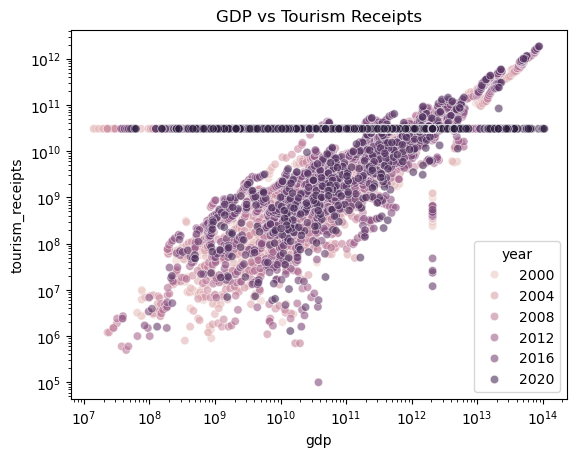

In [116]:
sns.scatterplot(data=df, x='gdp', y='tourism_receipts', hue='year', alpha=0.6)
plt.title('GDP vs Tourism Receipts')
plt.xscale('log')
plt.yscale('log')


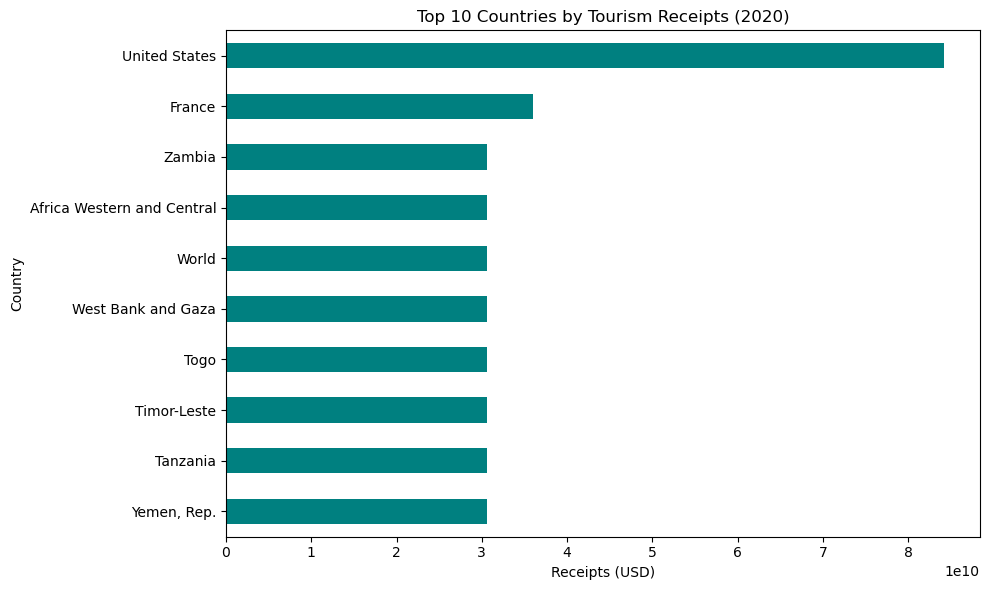

In [117]:
"""1.Top 10 Countries by Tourism Receipts (2020)"""
#step 1: calculate the KPI
top_receipts = df[df['year'] == 2020].groupby('country')['tourism_receipts'].sum().sort_values(ascending=False).head(10)

top_receipts.plot(kind='barh', figsize=(10,6), color='teal')
plt.title('Top 10 Countries by Tourism Receipts (2020)')
plt.xlabel('Receipts (USD)')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


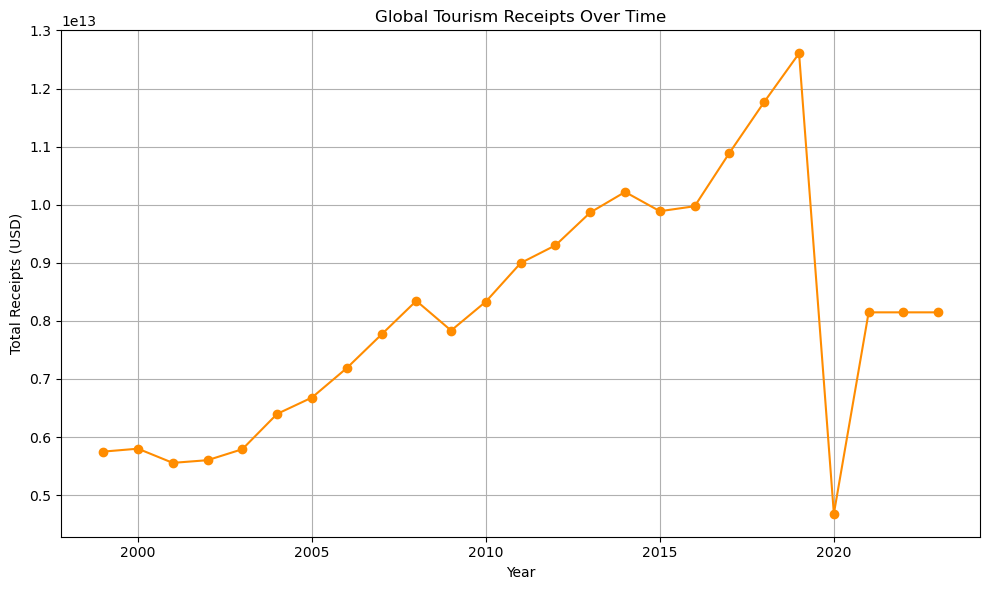

In [119]:
"""2.Global Tourism Receipts Over Time"""
# step1: calculate the KPI
trend = df.groupby('year')['tourism_receipts'].sum()

trend.plot(kind='line', marker='o', figsize=(10,6), color='darkorange')
plt.title('Global Tourism Receipts Over Time')
plt.ylabel('Total Receipts (USD)')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\dhakshina\AppData\Local\Temp\ipykernel_18984\3392331420.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




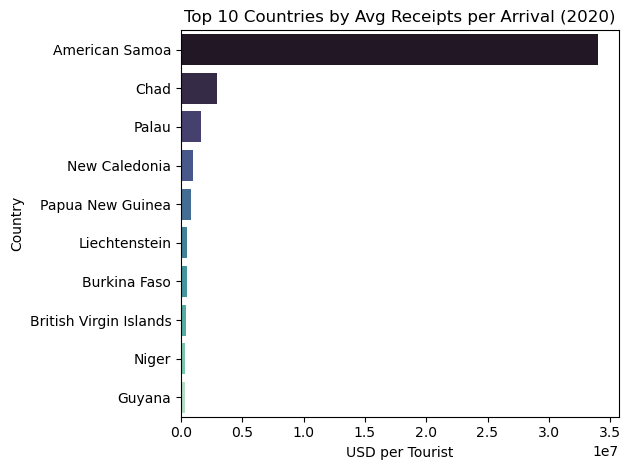

In [122]:
"""3.Top 10 Countries by Avg Receipts per Arrival (2020)"""
df['avg_receipts_per_arrival'] = df['tourism_receipts'] / df['tourism_arrivals']

top_avg = df[df['year'] == 2020].sort_values(by='avg_receipts_per_arrival', ascending=False).head(10)

sns.barplot(data=top_avg, x='avg_receipts_per_arrival', y='country', palette='mako')
plt.title('Top 10 Countries by Avg Receipts per Arrival (2020)')
plt.xlabel('USD per Tourist')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


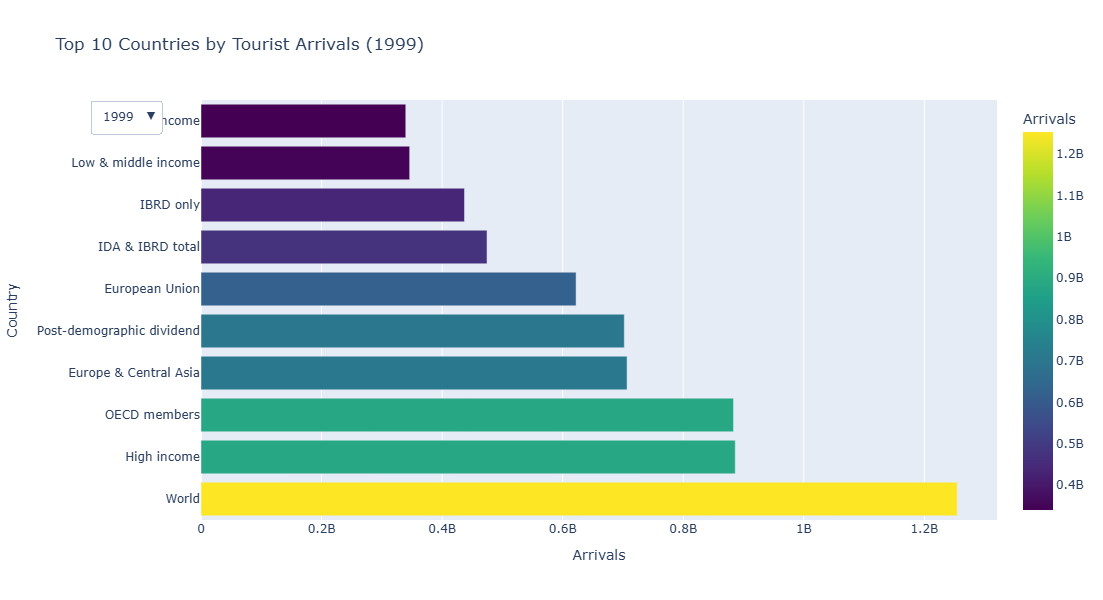

In [123]:
"""4 Top 10 Countries by Tourist Arrivals """
# Sample: Filter top 10 countries by arrivals for each year
def get_top10_by_year(df, year):
    df_year = df[df['year'] == year]
    return df_year.sort_values(by='tourism_arrivals', ascending=False).head(10)

# Create a list of unique years
years = sorted(df['year'].unique())

# Create a figure with dropdown
fig = px.bar(
    get_top10_by_year(df, years[0]),
    x='tourism_arrivals',
    y='country',
    orientation='h',
    title=f'Top 10 Countries by Tourist Arrivals ({years[0]})',
    labels={'tourism_arrivals': 'Arrivals', 'country': 'Country'},
    color='tourism_arrivals',
    color_continuous_scale='viridis'
)
# Add dropdown menu
fig.update_layout(
    updatemenus=[{
        'buttons': [
            {
                'label': str(year),
                'method': 'update',
                'args': [
                    {'x': [get_top10_by_year(df, year)['tourism_arrivals']],
                     'y': [get_top10_by_year(df, year)['country']]},
                    {'title': f'Top 10 Countries by Tourist Arrivals ({year})'}
                ]
            } for year in years
        ],
        'direction': 'down',
        'showactive': True,
    }]
)
fig.update_layout(height=600)
fig.show()


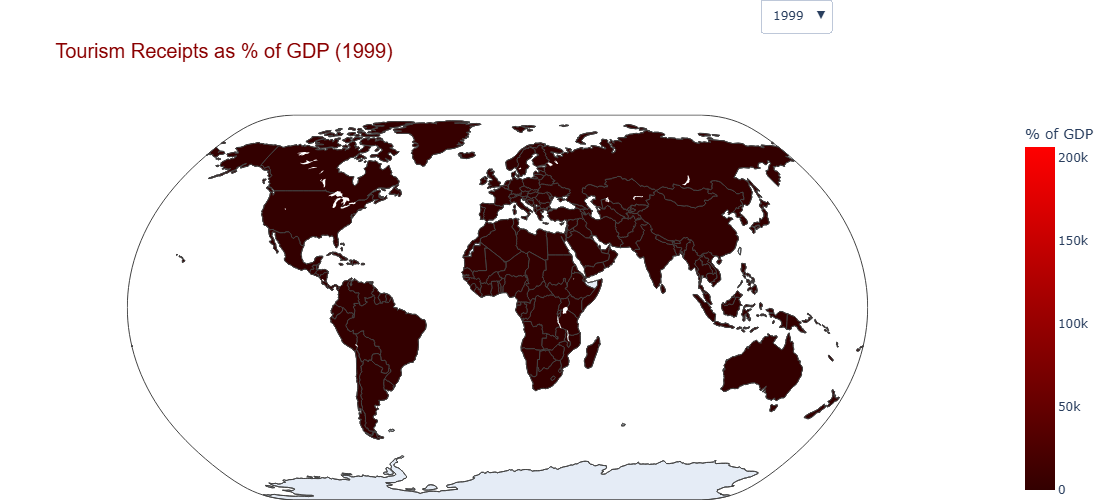

In [130]:
""" 5.Tourism Receipts as % of GDP """
# Step 1: Calculate the KPI
df['receipts_pct_gdp'] = (df['tourism_receipts'] / df['gdp']) * 100

# Step 2: Get list of unique years
years = sorted(df['year'].unique())

# Step 3: Create initial choropleth for the first year
color_scale = [
    [0.0, '#330000'],  # very dark red
    [0.5, '#990000'],  # medium red
    [1.0, '#ff0000']   # bright red
]
fig = px.choropleth(
    df[df['year'] == years[0]],
    locations='country_code',
    color='receipts_pct_gdp',
    hover_name='country',
    color_continuous_scale=color_scale,
    labels={'receipts_pct_gdp': '% of GDP'},
    title=f'Tourism Receipts as % of GDP ({years[0]})'
)

# Step 4: Add dropdown menu for year selection
fig.update_layout(
    title_font=dict(
        size=20,
        color='darkred',
        family='Arial'
    ),
    updatemenus=[{
        'buttons': [
            {
                'label': str(year),
                'method': 'update',
                'args': [
                    {
                        'z': [df[df['year'] == year]['receipts_pct_gdp']],
                        'locations': [df[df['year'] == year]['country_code']],
                        'hovertext': [df[df['year'] == year]['country']]
                    },
                    {
                        'title': f'Tourism Receipts as % of GDP ({year})'
                    }
                ],
            } for year in years
        ],
        'direction': 'down',
        'showactive': True,
        'x': 0.8,
        'xanchor': 'center',
        'y': 1.30,
        'yanchor': 'top'
    }],
    height=500,
    width=800,
    margin={"r":0, "t":50, "l":0, "b":0}
)


# Step 5: Update map styling
fig.update_geos(
    showcountries=True,
    showcoastlines=True,
    projection_type='natural earth'
)

fig.show()


C:\Users\dhakshina\AppData\Local\Temp\ipykernel_18984\3646144837.py:8: FutureWarning:

The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



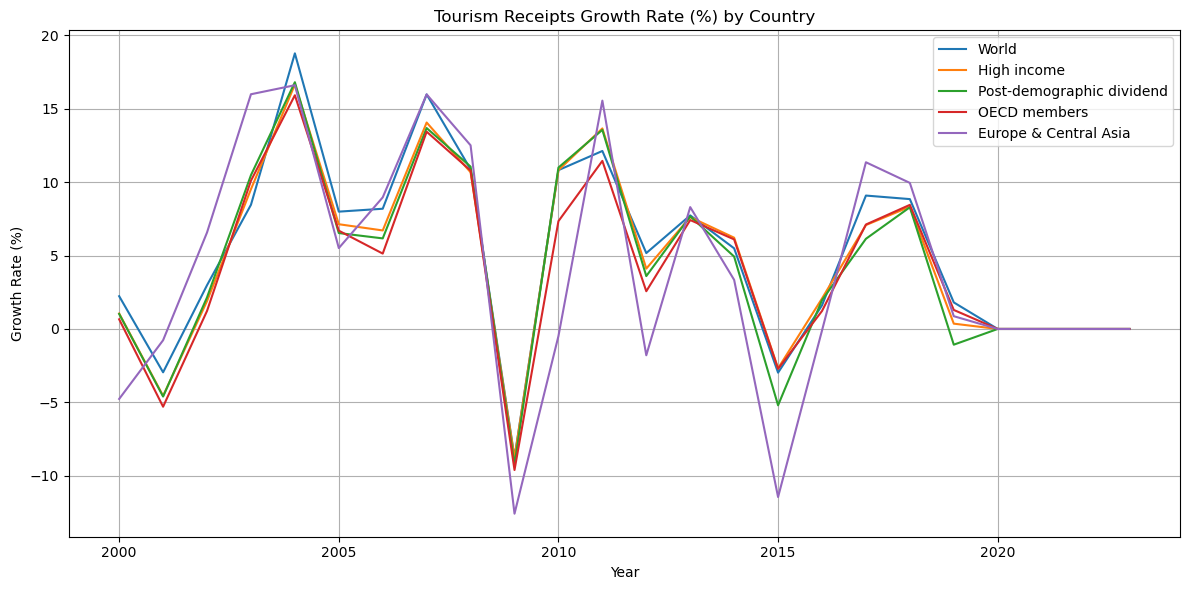

In [75]:
""" 6.Tourism Receipts Growth Rate (%) by Country """
import matplotlib.pyplot as plt

# Step 1: Sort data by country and year
df_sorted = df.sort_values(by=['country', 'year'])

# Step 2: Calculate YoY growth rate
df_sorted['receipts_growth_pct'] = df_sorted.groupby('country')['tourism_receipts'].pct_change() * 100

# Step 3: Select top countries for comparison
top_countries = df_sorted.groupby('country')['tourism_receipts'].sum().sort_values(ascending=False).head(5).index
df_top = df_sorted[df_sorted['country'].isin(top_countries)]

# Step 4: Plot
plt.figure(figsize=(12, 6))
for country in top_countries:
    country_data = df_top[df_top['country'] == country]
    plt.plot(country_data['year'], country_data['receipts_growth_pct'], label=country)

# Step 5: Styling
plt.title('Tourism Receipts Growth Rate (%) by Country')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


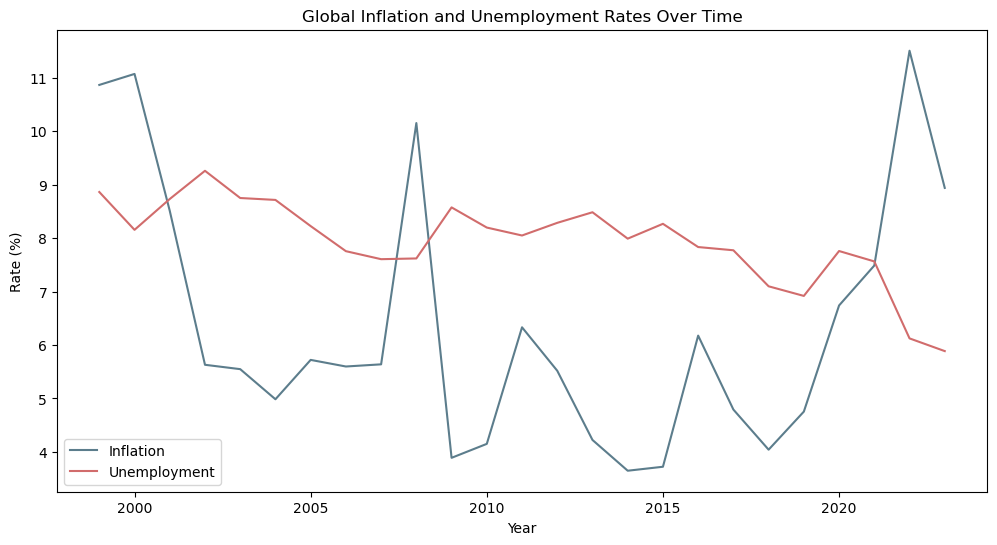

In [125]:
"""7.Global Inflation and Unemployment Rates Over Time """
# Inflation and Unemployment rate over time (global average)
plt.figure(figsize=(12, 6))
global_inflation = df.groupby('year')['inflation'].mean()
global_unemployment = df.groupby('year')['unemployment'].mean()

plt.plot(global_inflation, label='Inflation', color='#5C7D8C')
plt.plot(global_unemployment, label='Unemployment', color='#D16C6C')
plt.title('Global Inflation and Unemployment Rates Over Time')
plt.xlabel('Year')
plt.ylabel('Rate (%)')
plt.legend()
plt.grid(False)
plt.show()

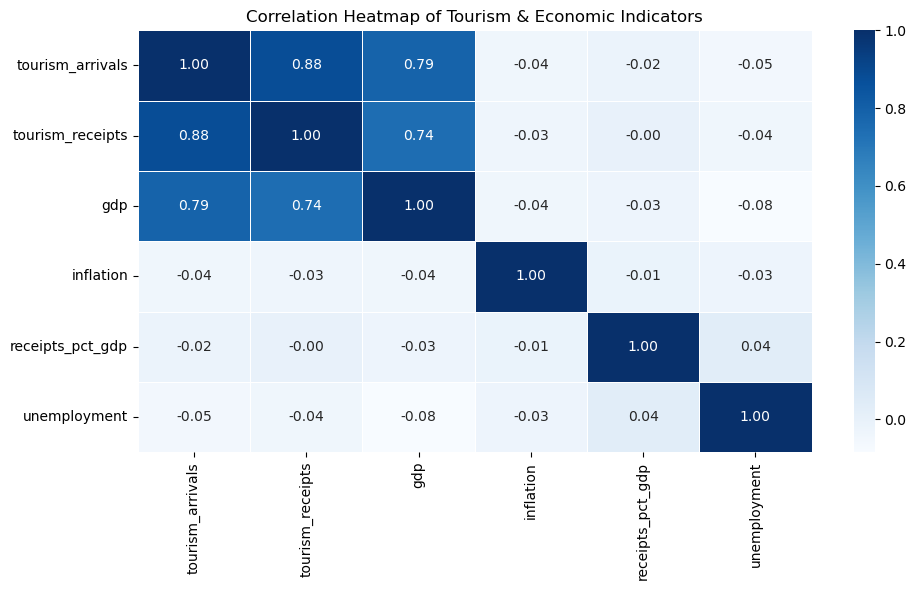

In [126]:
"""8.Correlation Heatmap of Key Tourism and Economic Indicators"""

# Step 1: Select relevant numeric columns
corr_columns = [
    'tourism_arrivals',
    'tourism_receipts',
    'gdp',
    'inflation',
    'receipts_pct_gdp',
    'unemployment'
    
]

# Step 2: Compute correlation matrix
corr_matrix = df[corr_columns].corr()

# Step 3: Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Tourism & Economic Indicators')
plt.tight_layout()
plt.show()


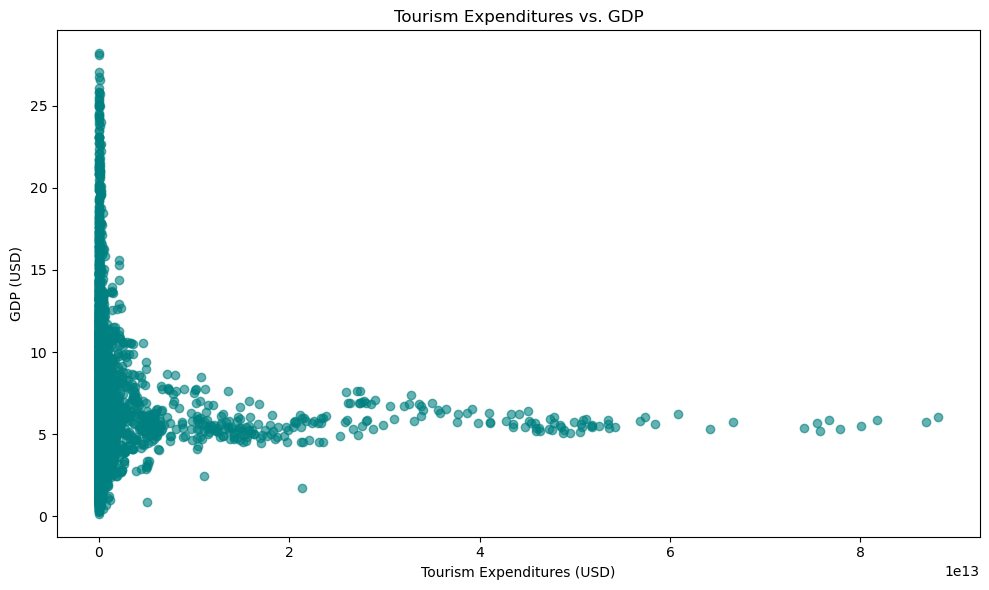

In [127]:
"""9.Tourism Expenditures vs. GDP"""
#  Scatter plot of tourism expenditures vs GDP
plt.figure(figsize=(10, 6))
plt.scatter(df['gdp'], df['tourism_expenditures'], alpha=0.6, color='teal')
plt.title('Tourism Expenditures vs. GDP')
plt.ylabel('GDP (USD)')
plt.xlabel('Tourism Expenditures (USD)')
plt.grid(False)
plt.tight_layout()
plt.show()


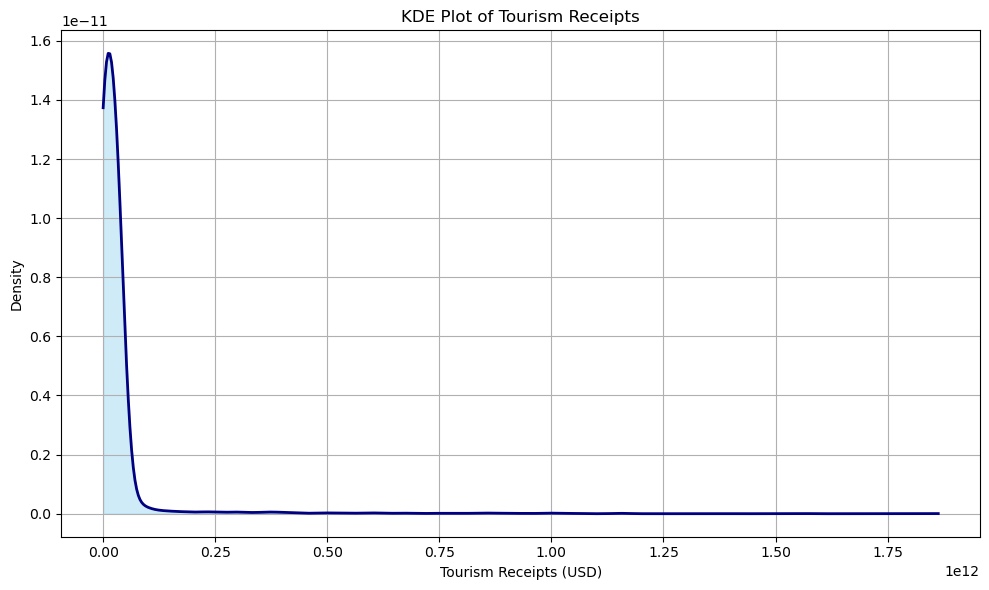

In [128]:
"""10.Distribution of Tourism Receipts"""
# Step 1: Prepare data
data = df['tourism_receipts'].dropna()

# Step 2: Compute KDE
kde = gaussian_kde(data)
x_vals = np.linspace(data.min(), data.max(), 500)
y_vals = kde(x_vals)

# Step 3: Plot using Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, color='navy', linewidth=2)
plt.fill_between(x_vals, y_vals, color='skyblue', alpha=0.4)
plt.title('KDE Plot of Tourism Receipts')
plt.xlabel('Tourism Receipts (USD)')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()
